# E9 - EfficientNet-B3, random oversampling, 224px

| | |
|---|---|
| Architecture | `efficientnet_b3` |
| Imbalance strategy | `oversampling` |
| Input resolution | 224x224 |
| Group | EfficientNet-B3 ablation |
| Optimiser | Adam, lr 1e-3, betas (0.9, 0.999) |
| Batch size | 32 |
| Schedule | max 50 epochs, early stopping on val loss, patience 10 |
| Seed | 42 |

B3 with oversampling, matching E5 and E6. Last of the 224px B3 runs, so
after this the whole matched-resolution comparison is available.

Training is checkpointed after every epoch. If the pod drops, re-run the training cell
and it picks up from the last completed epoch rather than starting over.

In [1]:
import json, sys, time
from pathlib import Path

# Works whether the kernel starts in notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "src" / "ham10000").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

# /workspace is a MooseFS network volume and per-file reads over FUSE were the
# bottleneck, not the GPU: 45 img/s there against 241 img/s from RAM. Notebook 01
# stages a copy into /dev/shm. Fall back to the on-disk copy if it is missing,
# since tmpfs does not survive a pod restart.
FAST = Path("/dev/shm/ham_data")
DATA = FAST if (FAST / "HAM10000_metadata.csv").exists() else ROOT / "data"
RUNS = ROOT / "runs"
print("repo:   ", ROOT)
print("data:   ", DATA, "(RAM)" if str(DATA).startswith("/dev/shm") else "(disk, slower)")

repo:    /workspace/ham10000-cnn-comparison
data:    /dev/shm/ham_data (RAM)


In [2]:
from ham10000.constants import EXPERIMENTS, experiment_label
from ham10000.train import TrainConfig, train_experiment

EXP = "E9"
print(experiment_label(EXP))
print(EXPERIMENTS[EXP])

E9 EfficientNet-B3 @224 / Random oversampling
{'architecture': 'efficientnet_b3', 'strategy': 'oversampling', 'image_size': 224}


## Preflight

Confirms the GPU, the data and the shared split before anything expensive starts.

In [3]:
import torch
from ham10000.split import load_or_create_split, split_hash

assert torch.cuda.is_available(), "No GPU. Stop here."
print("gpu :", torch.cuda.get_device_name(0))

assert (DATA / "HAM10000_metadata.csv").exists(), "Run notebook 01 first."
df, lesion_splits = load_or_create_split(DATA / "HAM10000_metadata.csv",
                                         RUNS / "splits" / "seed42_lesion_stratified.json")
print("split hash :", split_hash(lesion_splits))
print(df.split.value_counts().to_dict())

gpu : NVIDIA RTX A4500
split hash : f35ac1de18678182
{'train': 8012, 'test': 1024, 'val': 979}


## Train

Expect this to take a while. Roughly 30 to 60 minutes on an A40, depending on how early the run stops.

The cell is safe to re-run: if `test_metrics.json` already exists it returns the cached
result instead of retraining. Pass `force_rerun=True` if you genuinely want it redone.

In [4]:
config = TrainConfig(
    experiment_id=EXP,
    data_root=str(DATA),
    output_dir=str(RUNS / EXP),
    seed=42,
    batch_size=32,
    lr=1e-3,
    max_epochs=50,
    patience=10,
    num_workers=16,
)

start = time.time()
result = train_experiment(config)
print(f"\nwall clock: {(time.time() - start) / 60:.1f} min")

Epoch 1/50 | train loss 0.7843 acc 0.7152 | val loss 0.7689 macro-F1 0.5808
Epoch 2/50 | train loss 0.4914 acc 0.8248 | val loss 1.1029 macro-F1 0.6320
Epoch 3/50 | train loss 0.3897 acc 0.8588 | val loss 0.7420 macro-F1 0.6728
Epoch 4/50 | train loss 0.3194 acc 0.8865 | val loss 0.7893 macro-F1 0.6619
Epoch 5/50 | train loss 0.2730 acc 0.9020 | val loss 1.0162 macro-F1 0.6308
Epoch 6/50 | train loss 0.2625 acc 0.9058 | val loss 0.6644 macro-F1 0.6609
Epoch 7/50 | train loss 0.2342 acc 0.9158 | val loss 0.7570 macro-F1 0.6771
Epoch 8/50 | train loss 0.2441 acc 0.9148 | val loss 0.6289 macro-F1 0.7089
Epoch 9/50 | train loss 0.2002 acc 0.9287 | val loss 0.7194 macro-F1 0.6903
Epoch 10/50 | train loss 0.1759 acc 0.9363 | val loss 0.5875 macro-F1 0.7149
Epoch 11/50 | train loss 0.1834 acc 0.9370 | val loss 0.7208 macro-F1 0.7247
Epoch 12/50 | train loss 0.1791 acc 0.9396 | val loss 0.6562 macro-F1 0.7227
Epoch 13/50 | train loss 0.1621 acc 0.9425 | val loss 0.7012 macro-F1 0.7167
Epoch 14

## Results

In [5]:
import pandas as pd
from ham10000.constants import CLASS_NAMES

m = result["test_metrics"]
report = m["classification_report"]

print(f"accuracy          {m['accuracy']:.4f}")
print(f"balanced accuracy {m['balanced_accuracy']:.4f}")
print(f"macro F1          {m['macro_f1']:.4f}")
print(f"macro AUC (OvR)   {m['macro_auc_ovr']:.4f}\n")

table = pd.DataFrame([{
    "class": c,
    "precision": report[str(i)]["precision"],
    "recall": report[str(i)]["recall"],
    "f1": report[str(i)]["f1-score"],
    "support": int(report[str(i)]["support"]),
} for i, c in enumerate(CLASS_NAMES)]).set_index("class").round(4)
print(table)

rq2 = (report[str(CLASS_NAMES.index("mel"))]["recall"]
       + report[str(CLASS_NAMES.index("bcc"))]["recall"]) / 2
print(f"\nRQ2 criterion, mean(recall MEL, recall BCC) = {rq2:.4f}")

accuracy          0.8047
balanced accuracy 0.7611
macro F1          0.7043
macro AUC (OvR)   0.9584

       precision  recall      f1  support
class                                    
akiec     0.5349  0.6970  0.6053       33
bcc       0.6731  0.6604  0.6667       53
bkl       0.6415  0.6476  0.6445      105
df        0.6316  0.9231  0.7500       13
mel       0.5033  0.6696  0.5746      115
nv        0.9415  0.8638  0.9010      690
vasc      0.7222  0.8667  0.7879       15

RQ2 criterion, mean(recall MEL, recall BCC) = 0.6650


### Training curve

Val loss is what early stopping watches. Val macro F1 is what actually matters, and the
two do not always move together.

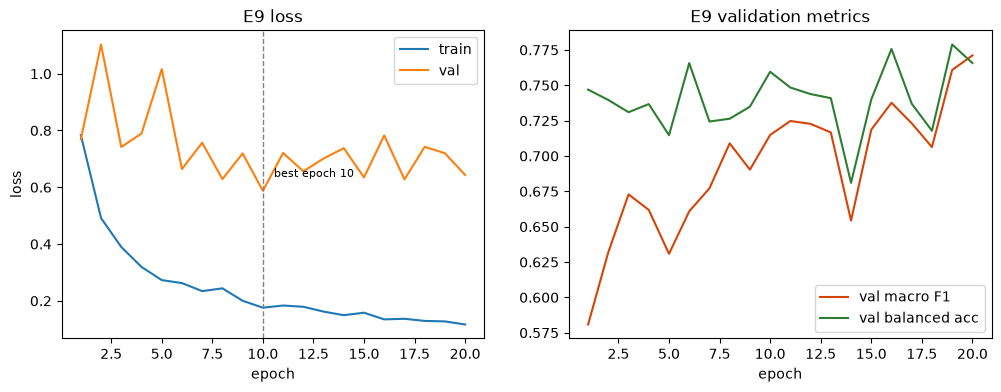

stopped after 20 epochs, best val loss 0.5875 at epoch 10


In [6]:
import matplotlib.pyplot as plt

h = pd.read_csv(RUNS / EXP / "history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h.epoch, h.train_loss, label="train")
axes[0].plot(h.epoch, h.val_loss, label="val")
best = h.loc[h.val_loss.idxmin()]
axes[0].axvline(best.epoch, ls="--", c="grey", lw=1)
axes[0].annotate(f"best epoch {int(best.epoch)}", (best.epoch, best.val_loss),
                 textcoords="offset points", xytext=(8, 10), fontsize=8)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title(f"{EXP} loss")

axes[1].plot(h.epoch, h.val_macro_f1, color="#D54407", label="val macro F1")
axes[1].plot(h.epoch, h.val_balanced_accuracy, color="#2E7D32", label="val balanced acc")
axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].set_title(f"{EXP} validation metrics")
plt.show()

print(f"stopped after {len(h)} epochs, best val loss {h.val_loss.min():.4f} at epoch {int(best.epoch)}")

### Confusion matrix

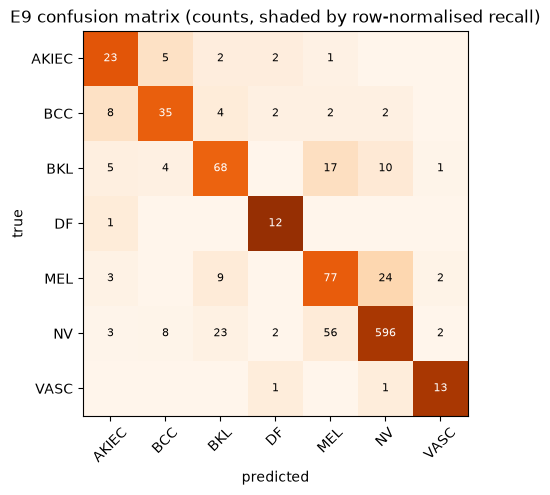

melanomas called NV: 24 of 115
This is the clinically costly error: a cancer sent home as a benign mole.


In [7]:
import numpy as np

cm = np.array(m["confusion_matrix"], dtype=float)
norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(norm, cmap="Oranges", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        if cm[i, j]:
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if norm[i, j] > 0.55 else "black")
ax.set_xticks(range(7), [c.upper() for c in CLASS_NAMES], rotation=45)
ax.set_yticks(range(7), [c.upper() for c in CLASS_NAMES])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{EXP} confusion matrix (counts, shaded by row-normalised recall)")
ax.grid(False)
plt.show()

mel, nv = CLASS_NAMES.index("mel"), CLASS_NAMES.index("nv")
print(f"melanomas called NV: {int(cm[mel, nv])} of {int(cm[mel].sum())}")
print("This is the clinically costly error: a cancer sent home as a benign mole.")

### Files written

These five are what the analysis notebooks read. Nothing later re-derives them.

In [8]:
for f in sorted((RUNS / EXP).iterdir()):
    print(f"{f.name:<24} {f.stat().st_size/1e6:>8.2f} MB")

checkpoint_best.pt         129.34 MB
checkpoint_last.pt         129.34 MB
config.json                  0.00 MB
history.csv                  0.00 MB
test_metrics.json            0.00 MB
test_predictions.csv         0.02 MB
